# Case Study 3 — Research Question 2: Does Cross-Country Dependence Improve Forecasts?

This notebook addresses **RQ2**: when and to what extent does cross-country COVID-19 dependence provide forecast value beyond strong country-specific baseline models?

The analysis proceeds in three stages:

1. **Benchmark selection** — for each of the seven countries, SARIMA and ETS models are fitted and the better-performing univariate specification is selected via AIC. These benchmarks are deliberately demanding: they capture within-country autocorrelation, seasonality, and trend, so any multivariate model must clear a high bar.

2. **Expanding-window evaluation** — both the selected benchmarks and the multivariate alternatives (VAR(2), VAR(3)) are evaluated using a consistent expanding-window one-step-ahead design with 169 forecast origins, ensuring a fair like-for-like comparison on the same transformed target series.

3. **Robustness check via hhh4** — results from an endemic-epidemic (`hhh4`) model fitted in R are loaded and visualised to confirm whether the VAR conclusions hold under a model designed specifically for multivariate infectious-disease count data.

Pre-computed figures are saved to `../Results/Figures/` and scalar results to `comparison_with_hhh4.csv` for use in the executive report.

## Data Preparation

In [1]:
import pandas as pd
import numpy as np

# Read data
path = "../Data/AllNationsCombined.csv"
df = pd.read_csv(path)

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Standardized columns:")
print(df.columns.tolist())

# Rename columns to simpler names
df = df.rename(columns={
    "countryname": "country",
    "date": "date",
    "countvalue": "cases",
    "totalpopulation": "population",
    "cases_per_100,000": "cases_per_100k"
})

# Parse date
df["date"] = pd.to_datetime(df["date"])

# Harmonize country names
df["country"] = df["country"].astype(str).str.strip()
df["country"] = df["country"].replace({
    "UNITED STATES OF AMERICA": "United States",
    "UNITED KINGDOM": "United Kingdom",
    "SOUTH AFRICA": "South Africa",
    "AUSTRALIA": "Australia",
    "BRAZIL": "Brazil",
    "CANADA": "Canada",
    "CHINA": "China",
    "United States Of America": "United States"
})

selected_countries = [
    "Australia", "Brazil", "Canada", "China",
    "South Africa", "United Kingdom", "United States"
]

# Keep only selected countries
df = df[df["country"].isin(selected_countries)].copy()

# Keep required columns
df = df[["country", "date", "cases", "population", "cases_per_100k"]]
df = df.sort_values(["country", "date"]).reset_index(drop=True)

# Create balanced panel
full_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
full_index = pd.MultiIndex.from_product(
    [selected_countries, full_dates],
    names=["country", "date"]
)

panel_df = (
    df.set_index(["country", "date"])
      .reindex(full_index)
      .reset_index()
      .sort_values(["country", "date"])
      .reset_index(drop=True)
)

# Fill population values within each country
panel_df["population"] = (
    panel_df.groupby("country")["population"]
    .transform(lambda s: s.ffill().bfill())
)

# Interpolate if needed
panel_df["cases"] = (
    panel_df.groupby("country")["cases"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

panel_df["cases_per_100k"] = (
    panel_df.groupby("country")["cases_per_100k"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

# Construct transformed variables
panel_df["log_cases"] = np.log1p(panel_df["cases"])
panel_df["log_cases_per_100k"] = np.log1p(panel_df["cases_per_100k"])

panel_df["ma7_cases_per_100k"] = (
    panel_df.groupby("country")["cases_per_100k"]
    .transform(lambda s: s.rolling(window=7, min_periods=7).mean())
)

panel_df["ma14_cases_per_100k"] = (
    panel_df.groupby("country")["cases_per_100k"]
    .transform(lambda s: s.rolling(window=14, min_periods=14).mean())
)

panel_df["ma7_log_cases_per_100k"] = np.log1p(panel_df["ma7_cases_per_100k"])
panel_df["ma14_log_cases_per_100k"] = np.log1p(panel_df["ma14_cases_per_100k"])

# Basic checks
print(panel_df.shape)
print(panel_df["country"].value_counts().sort_index())
print(panel_df[["country", "date", "cases", "cases_per_100k", "ma7_log_cases_per_100k"]].head(15))

Standardized columns:
['conditionname', 'outcome', 'countryname', 'date', 'sourcename', 'countvalue', 'totalpopulation', 'cases_per_100,000', 'partofcumulativecountseries']
(4025, 11)
country
Australia         575
Brazil            575
Canada            575
China             575
South Africa      575
United Kingdom    575
United States     575
Name: count, dtype: int64
      country       date  cases  cases_per_100k  ma7_log_cases_per_100k
0   Australia 2020-01-04      0             0.0                     NaN
1   Australia 2020-01-05      0             0.0                     NaN
2   Australia 2020-01-06      0             0.0                     NaN
3   Australia 2020-01-07      0             0.0                     NaN
4   Australia 2020-01-08      0             0.0                     NaN
5   Australia 2020-01-09      0             0.0                     NaN
6   Australia 2020-01-10      0             0.0                     0.0
7   Australia 2020-01-11      0             0.0     

### EDA and Validation

We plot the raw and smoothed per-capita series for each country to visually confirm alignment and check for obvious data issues (e.g., implausible spikes, missing stretches) before any modelling. The target variable for all univariate and VAR models is the **log-transformed 7-day smoothed cases per 100,000 population** (`ma7_log_cases_per_100k`). This transformation reduces skewness, stabilises variance, and places all countries on a comparable scale.

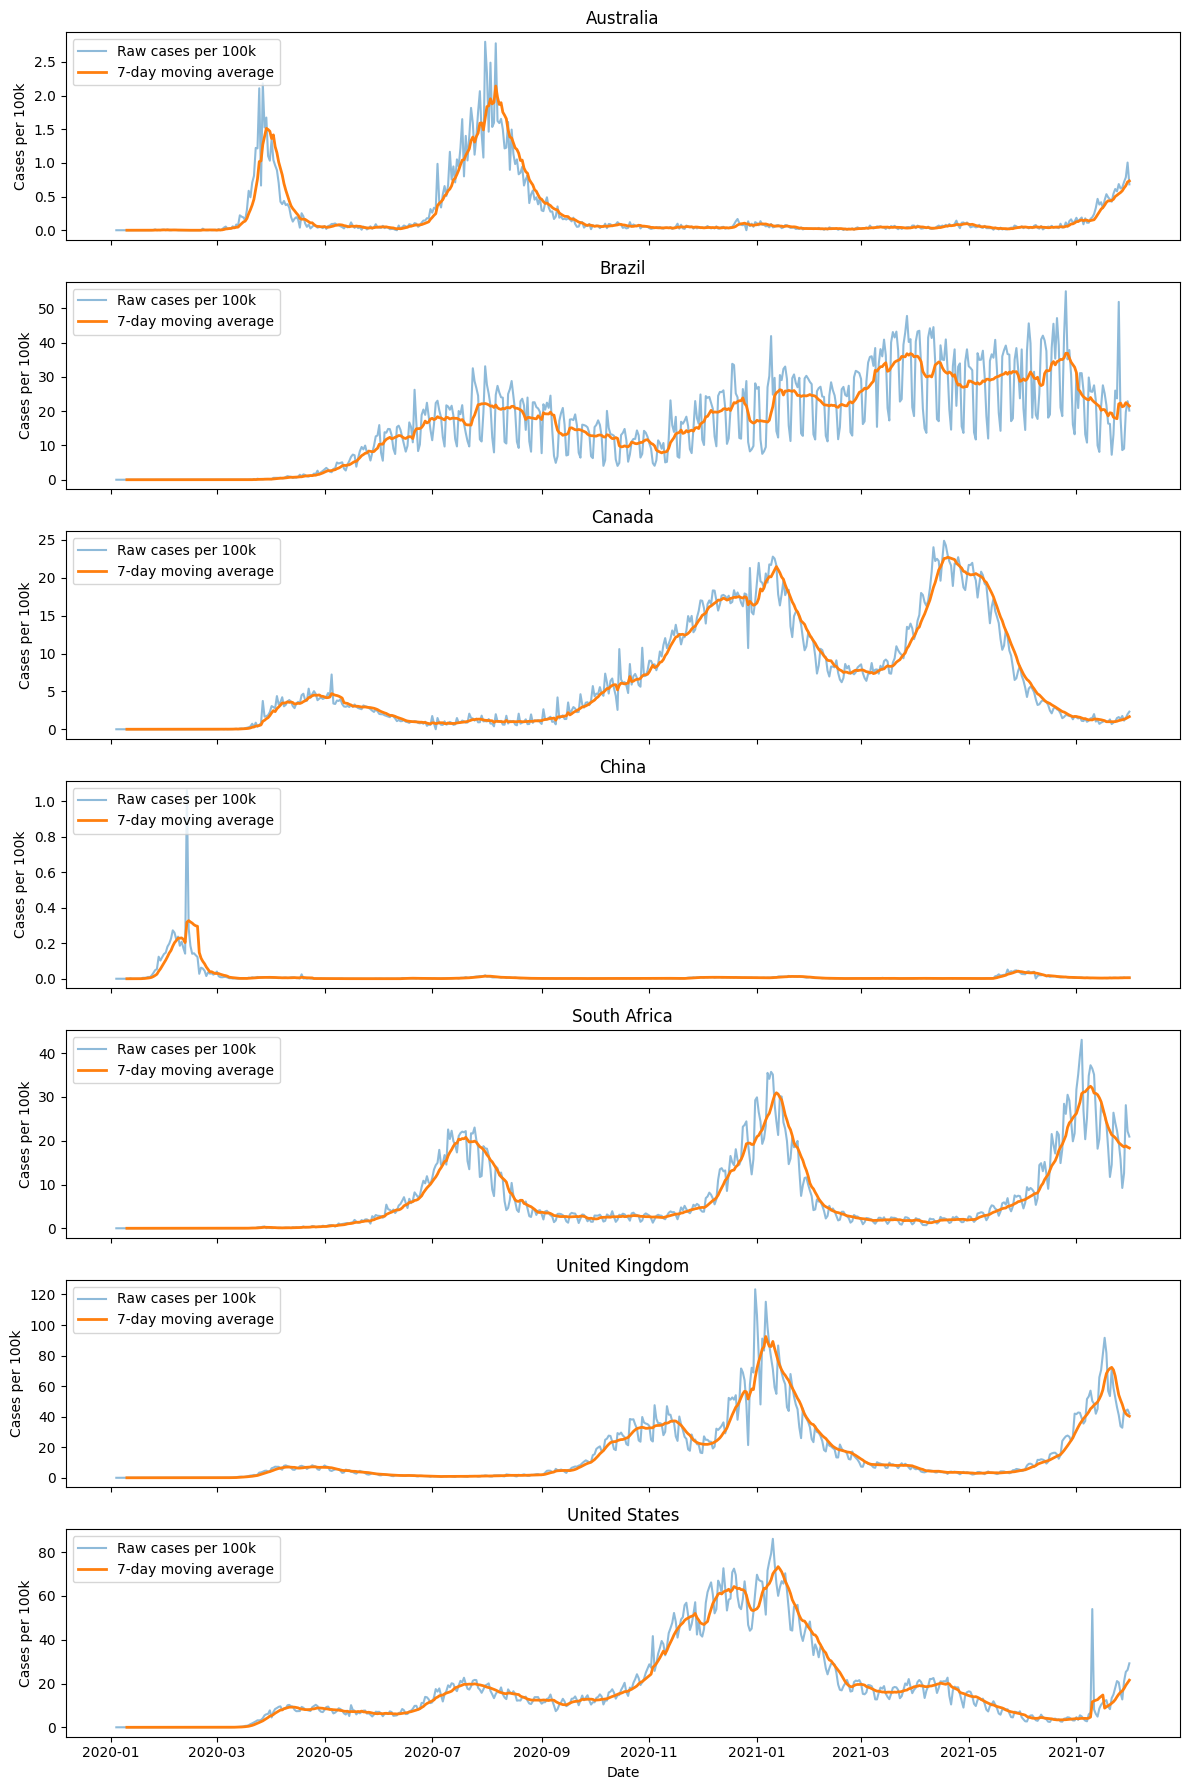

In [2]:
import matplotlib.pyplot as plt

countries = selected_countries

fig, axes = plt.subplots(nrows=len(countries), ncols=1, figsize=(12, 18), sharex=True)

for i, country in enumerate(countries):
    temp = panel_df[panel_df["country"] == country].copy()
    
    axes[i].plot(temp["date"], temp["cases_per_100k"], label="Raw cases per 100k", alpha=0.5)
    axes[i].plot(temp["date"], temp["ma7_cases_per_100k"], label="7-day moving average", linewidth=2)
    axes[i].set_title(country)
    axes[i].legend(loc="upper left")
    axes[i].set_ylabel("Cases per 100k")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## Benchmark: Univariate Models

For each country we fit two univariate candidate models over the full training series and select the one with lower AIC:

- **SARIMA** — selected via grid search over $(p, d, q) \times (P, D, Q)_7$ with $p, q, P, Q \in \{0, 1, 2\}$ and $d, D \in \{0, 1\}$, giving 144 candidate specifications per country.
- **ETS** — Exponential Smoothing with automatic error/trend/seasonal component selection via `statsmodels`.

The selected model per country serves as the **country-specific benchmark** for the expanding-window evaluation in the next section. A cross-country model must outperform this benchmark to be considered operationally useful.

In [3]:
import warnings
import numpy as np
import pandas as pd

from itertools import product
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

target_col = "ma7_log_cases_per_100k"
test_size = 60
seasonal_period = 7

In [ ]:
# Helper functions

def fit_best_sarima(train_series, seasonal_period=7):
    """Select the best SARIMA specification for a univariate series via AIC grid search.

    Searches over all combinations of (p, d, q) x (P, D, Q)_s where
    p, q, P, Q in {0, 1, 2} and d, D in {0, 1}, giving 144 candidates.
    The specification with the lowest finite AIC is returned.

    Args:
        train_series: 1-D array-like of training observations.
        seasonal_period: Seasonal period (default 7 for daily data with weekly seasonality).

    Returns:
        dict with keys:
            best_aic (float): AIC of the selected model.
            best_order (tuple): Non-seasonal (p, d, q) order.
            best_seasonal_order (tuple): Seasonal (P, D, Q, s) order.
            best_result: Fitted statsmodels SARIMAXResults object, or None if all fits failed.
    """
    best_aic = np.inf
    best_order = None
    best_seasonal_order = None
    best_result = None

    p_values = [0, 1, 2]
    d_values = [0, 1]
    q_values = [0, 1, 2]

    P_values = [0, 1]
    D_values = [0, 1]
    Q_values = [0, 1]

    for order in product(p_values, d_values, q_values):
        for seasonal in product(P_values, D_values, Q_values):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], seasonal_period)

            try:
                model = SARIMAX(
                    train_series,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                result = model.fit(disp=False)

                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_result = result
            except:
                continue

    return {
        "best_aic": best_aic,
        "best_order": best_order,
        "best_seasonal_order": best_seasonal_order,
        "best_result": best_result
    }


def fit_best_ets(train_series, seasonal_period=7):
    """Select the best ETS specification for a univariate series via AIC grid search.

    Searches over all combinations of trend in {None, 'add'} and
    seasonal in {None, 'add'}, giving 4 candidates. The specification
    with the lowest finite AIC is returned.

    Args:
        train_series: 1-D array-like of training observations.
        seasonal_period: Seasonal period (default 7).

    Returns:
        dict with keys:
            best_aic (float): AIC of the selected model.
            best_spec (str): Human-readable label, e.g. 'ETS(add,None)'.
            best_result: Fitted statsmodels HoltWintersResults object, or None if all fits failed.
    """
    best_aic = np.inf
    best_spec = None
    best_result = None

    trend_options = [None, "add"]
    seasonal_options = [None, "add"]

    for trend in trend_options:
        for seasonal in seasonal_options:
            if trend is None and seasonal is None:
                spec_name = "ETS(None,None)"
            elif trend is None:
                spec_name = f"ETS(None,{seasonal})"
            elif seasonal is None:
                spec_name = f"ETS({trend},None)"
            else:
                spec_name = f"ETS({trend},{seasonal})"

            try:
                model = ExponentialSmoothing(
                    train_series,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=seasonal_period,
                    initialization_method="estimated"
                )
                result = model.fit(optimized=True, use_brute=True)

                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_aic = result.aic
                    best_spec = spec_name
                    best_result = result
            except:
                continue

    return {
        "best_aic": best_aic,
        "best_spec": best_spec,
        "best_result": best_result
    }


def evaluate_forecast(y_true, y_pred):
    """Compute RMSE and MAE between actual and predicted values.

    Args:
        y_true: Array-like of actual observations.
        y_pred: Array-like of predicted values, same length as y_true.

    Returns:
        tuple: (rmse, mae) as floats.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae


In [ ]:
# Get the benchmarks selection for all countries
benchmark_results = []
benchmark_forecasts = {}

for country in selected_countries:
    temp = (
        panel_df.loc[panel_df["country"] == country, ["date", target_col]]
        .dropna()
        .reset_index(drop=True)
    )
    
    train = temp.iloc[:-test_size].copy()
    test = temp.iloc[-test_size:].copy()
    
    y_train = train[target_col]
    y_test = test[target_col]
    
    print(f"Processing {country} ...")
    
    # SARIMA
    sarima_fit = fit_best_sarima(y_train, seasonal_period=seasonal_period)
    
    if sarima_fit["best_result"] is not None:
        sarima_forecast = sarima_fit["best_result"].forecast(steps=test_size)
        sarima_rmse, sarima_mae = evaluate_forecast(y_test, sarima_forecast)
    else:
        sarima_forecast = pd.Series([np.nan] * test_size, index=test.index)
        sarima_rmse, sarima_mae = np.nan, np.nan
    
    # ETS
    ets_fit = fit_best_ets(y_train, seasonal_period=seasonal_period)
    
    if ets_fit["best_result"] is not None:
        ets_forecast = ets_fit["best_result"].forecast(test_size)
        ets_rmse, ets_mae = evaluate_forecast(y_test, ets_forecast)
    else:
        ets_forecast = pd.Series([np.nan] * test_size, index=test.index)
        ets_rmse, ets_mae = np.nan, np.nan
    
    benchmark_results.append({
        "country": country,
        "train_size": len(train),
        "test_size": len(test),
        "sarima_order": sarima_fit["best_order"],
        "sarima_seasonal_order": sarima_fit["best_seasonal_order"],
        "sarima_aic": sarima_fit["best_aic"],
        "sarima_rmse": sarima_rmse,
        "sarima_mae": sarima_mae,
        "ets_spec": ets_fit["best_spec"],
        "ets_aic": ets_fit["best_aic"],
        "ets_rmse": ets_rmse,
        "ets_mae": ets_mae
    })
    
    benchmark_forecasts[country] = {
        "train": train.copy(),
        "test": test.copy(),
        "sarima_forecast": np.array(sarima_forecast),
        "ets_forecast": np.array(ets_forecast)
    }

benchmark_results_df = pd.DataFrame(benchmark_results)
# benchmark_results_df

Processing Australia ...
Processing Brazil ...
Processing Canada ...
Processing China ...
Processing South Africa ...
Processing United Kingdom ...
Processing United States ...


,country,train_size,test_size,sarima_order,sarima_seasonal_order,sarima_aic,sarima_rmse,sarima_mae,ets_spec,ets_aic,ets_rmse,ets_mae
0,Australia,509,60,"(2, 1, 2)","(1, 0, 1, 7)",-3055.785654,0.211628,0.139696,"ETS(add,None)",-4309.188237,0.155151,0.098885
1,Brazil,509,60,"(2, 1, 1)","(0, 0, 1, 7)",-2180.584208,0.244707,0.200903,"ETS(add,None)",-3503.240389,0.160070,0.125468
2,Canada,509,60,"(1, 1, 2)","(0, 0, 1, 7)",-2274.366993,0.200947,0.178592,"ETS(add,None)",-3634.695869,1.013206,0.783178
3,China,509,60,"(2, 0, 1)","(1, 0, 1, 7)",-3814.578497,0.016395,0.015340,"ETS(add,None)",-4998.899210,0.043101,0.039359
4,South Africa,509,60,"(1, 1, 2)","(1, 0, 0, 7)",-2522.015271,0.637069,0.554999,"ETS(add,None)",-3913.337698,0.464017,0.380614
5,United Kingdom,509,60,"(2, 0, 1)","(0, 0, 0, 7)",-2640.849612,1.444554,1.247337,"ETS(add,None)",-4084.334293,0.531271,0.453228
6,United States,509,60,"(2, 1, 0)","(0, 0, 1, 7)",-2804.297144,0.838193,0.562351,"ETS(add,None)",-4196.336240,1.302635,0.918751


In [12]:
benchmark_results_df["best_model_by_rmse"] = np.where(
    benchmark_results_df["sarima_rmse"] <= benchmark_results_df["ets_rmse"],
    "SARIMA",
    "ETS"
)

benchmark_results_df["best_rmse"] = benchmark_results_df[["sarima_rmse", "ets_rmse"]].min(axis=1)
benchmark_results_df["best_mae"] = benchmark_results_df[["sarima_mae", "ets_mae"]].min(axis=1)

benchmark_results_df = benchmark_results_df.sort_values("country").reset_index(drop=True)

summary_table = benchmark_results_df[
    [
        "country",
        "sarima_order",
        "sarima_seasonal_order",
        "sarima_rmse",
        "sarima_mae",
        "ets_spec",
        "ets_rmse",
        "ets_mae",
        "best_model_by_rmse"
    ]
].copy()

# print(summary_table)

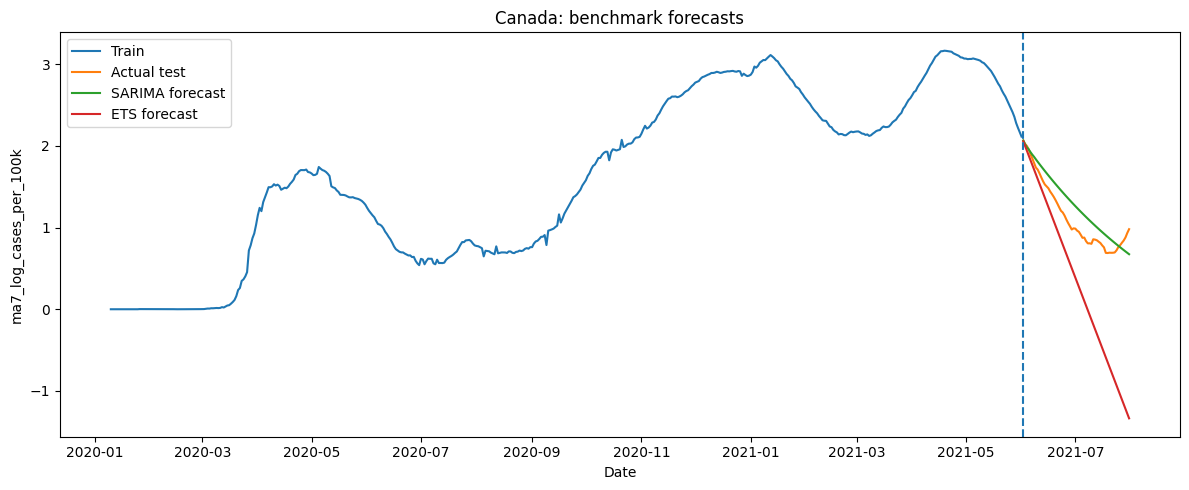

In [11]:
import matplotlib.pyplot as plt

country = "Canada"
obj = benchmark_forecasts[country]

train = obj["train"]
test = obj["test"]
sarima_forecast = obj["sarima_forecast"]
ets_forecast = obj["ets_forecast"]

plt.figure(figsize=(12, 5))
plt.plot(train["date"], train[target_col], label="Train")
plt.plot(test["date"], test[target_col], label="Actual test")
plt.plot(test["date"], sarima_forecast, label="SARIMA forecast")
plt.plot(test["date"], ets_forecast, label="ETS forecast")
plt.axvline(test["date"].iloc[0], linestyle="--")
plt.title(f"{country}: benchmark forecasts")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
benchmark_results_df["selected_benchmark"] = np.where(
    benchmark_results_df["sarima_rmse"] <= benchmark_results_df["ets_rmse"],
    "SARIMA",
    "ETS"
)

benchmark_results_df["selected_benchmark_rmse"] = benchmark_results_df[["sarima_rmse", "ets_rmse"]].min(axis=1)
benchmark_results_df["selected_benchmark_mae"] = benchmark_results_df[["sarima_mae", "ets_mae"]].min(axis=1)

print(
    benchmark_results_df[
        [
            "country",
            "selected_benchmark",
            "selected_benchmark_rmse",
            "selected_benchmark_mae"
        ]
    ].sort_values("country")
)

          country selected_benchmark  selected_benchmark_rmse  \
0       Australia                ETS                 0.155151   
1          Brazil                ETS                 0.160070   
2          Canada             SARIMA                 0.200947   
3           China             SARIMA                 0.016395   
4    South Africa                ETS                 0.464017   
5  United Kingdom                ETS                 0.531271   
6   United States             SARIMA                 0.838193   

   selected_benchmark_mae  
0                0.098885  
1                0.125468  
2                0.178592  
3                0.015340  
4                0.380614  
5                0.453228  
6                0.562351  


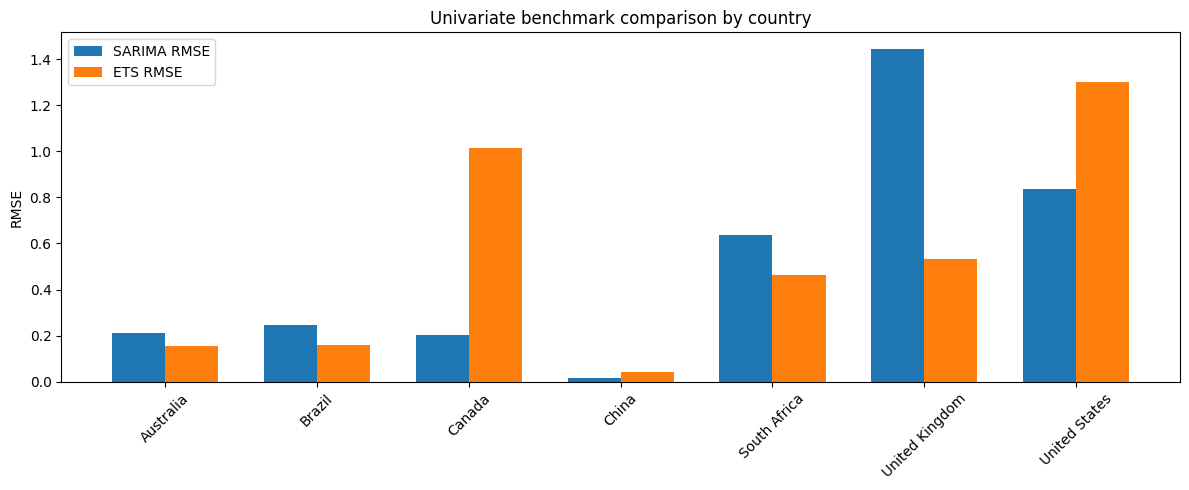

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = benchmark_results_df.sort_values("country").copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, plot_df["sarima_rmse"], width=width, label="SARIMA RMSE")
plt.bar(x + width/2, plot_df["ets_rmse"], width=width, label="ETS RMSE")

plt.xticks(x, plot_df["country"], rotation=45)
plt.ylabel("RMSE")
plt.title("Univariate benchmark comparison by country")
plt.legend()
plt.tight_layout()
plt.show()

We have now selected the best univariate model per country (SARIMA or ETS by AIC). The next step is a rigorous **expanding-window one-step-ahead evaluation** to measure out-of-sample forecast accuracy.

**Evaluation design:**
- **169 forecast origins**, expanding the training window by one day at each step (starting from `initial_train_size = 400`).
- At each origin the selected model is re-fitted on all data up to that point, then used to produce a one-step-ahead forecast.
- Accuracy is measured by **RMSE** and **MAE** on the same transformed scale used for model fitting (`ma7_log_cases_per_100k`).
- The same design is applied identically to the VAR models below, ensuring a fair comparison.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

target_col = "ma7_log_cases_per_100k"
seasonal_period = 7
initial_train_size = 400


def fit_sarima_with_spec(train_series, order, seasonal_order):
    """Fit a SARIMA model with a fixed, pre-specified order.

    Unlike fit_best_sarima, this function does not search over orders;
    it is used during the expanding-window evaluation where the order
    was already selected in the benchmark phase.

    Args:
        train_series: 1-D array-like of training observations.
        order (tuple): Non-seasonal (p, d, q) order.
        seasonal_order (tuple): Seasonal (P, D, Q, s) order.

    Returns:
        Fitted statsmodels SARIMAXResults object.
    """
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False)
    return result


def parse_ets_spec(ets_spec):
    """Parse an ETS spec string into (trend, seasonal) component labels.

    Args:
        ets_spec (str): Spec string in the format 'ETS(trend,seasonal)',
            e.g. 'ETS(add,None)' or 'ETS(None,add)'.

    Returns:
        tuple: (trend, seasonal) where each is either None or 'add'.

    Raises:
        ValueError: If ets_spec is not a recognised format.
    """
    if ets_spec == "ETS(None,None)":
        return None, None
    if ets_spec == "ETS(None,add)":
        return None, "add"
    if ets_spec == "ETS(add,None)":
        return "add", None
    if ets_spec == "ETS(add,add)":
        return "add", "add"
    raise ValueError(f"Unsupported ETS spec: {ets_spec}")


def fit_ets_with_spec(train_series, ets_spec, seasonal_period=7):
    """Fit an ETS model with a fixed, pre-specified component structure.

    Args:
        train_series: 1-D array-like of training observations.
        ets_spec (str): Spec string as returned by fit_best_ets, e.g. 'ETS(add,None)'.
        seasonal_period (int): Seasonal period (default 7).

    Returns:
        Fitted statsmodels HoltWintersResults object.
    """
    trend, seasonal = parse_ets_spec(ets_spec)
    model = ExponentialSmoothing(
        train_series,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_period,
        initialization_method="estimated"
    )
    result = model.fit(optimized=True, use_brute=True)
    return result


def rolling_selected_benchmark_forecast(
    panel_df,
    benchmark_results_df,
    country,
    target_col="ma7_log_cases_per_100k",
    initial_train_size=400,
    seasonal_period=7
):
    """Run expanding-window one-step-ahead forecasts for a single country's benchmark model.

    At each forecast origin t (from initial_train_size to end of series),
    the pre-selected benchmark model (SARIMA or ETS) is re-fitted on all
    observations up to t-1 and used to predict observation t.

    Args:
        panel_df: Full balanced panel DataFrame with columns 'country', 'date', target_col.
        benchmark_results_df: DataFrame from the benchmark selection phase containing
            'country', 'selected_benchmark', 'sarima_order', 'sarima_seasonal_order', 'ets_spec'.
        country (str): Country name to evaluate.
        target_col (str): Name of the target column (default 'ma7_log_cases_per_100k').
        initial_train_size (int): Minimum number of observations before the first forecast.
        seasonal_period (int): Seasonal period passed to the model (default 7).

    Returns:
        pd.DataFrame with one row per forecast origin and columns:
        country, date, model, actual, forecast, error, abs_error, sq_error, success.
    """
    temp = (
        panel_df.loc[panel_df["country"] == country, ["date", target_col]]
        .dropna()
        .reset_index(drop=True)
    )

    row = benchmark_results_df.loc[benchmark_results_df["country"] == country].iloc[0]
    selected_model = row["selected_benchmark"]

    records = []

    for t in range(initial_train_size, len(temp)):
        train_series = temp.loc[:t - 1, target_col]
        test_date = temp.loc[t, "date"]
        actual = temp.loc[t, target_col]

        try:
            if selected_model == "SARIMA":
                fitted = fit_sarima_with_spec(
                    train_series=train_series,
                    order=row["sarima_order"],
                    seasonal_order=row["sarima_seasonal_order"]
                )
                forecast = fitted.forecast(steps=1)
                pred = float(forecast.iloc[0])

            elif selected_model == "ETS":
                fitted = fit_ets_with_spec(
                    train_series=train_series,
                    ets_spec=row["ets_spec"],
                    seasonal_period=seasonal_period
                )
                forecast = fitted.forecast(1)
                pred = float(forecast.iloc[0])

            else:
                raise ValueError(f"Unknown selected model: {selected_model}")

            error = actual - pred
            abs_error = abs(error)
            sq_error = error ** 2
            success = 1

        except Exception:
            pred = np.nan
            error = np.nan
            abs_error = np.nan
            sq_error = np.nan
            success = 0

        records.append({
            "country": country,
            "date": test_date,
            "model": selected_model,
            "actual": actual,
            "forecast": pred,
            "error": error,
            "abs_error": abs_error,
            "sq_error": sq_error,
            "success": success
        })

    return pd.DataFrame(records)


rolling_benchmark_list = []

for country in selected_countries:
    print(f"Running rolling selected benchmark for {country} ...")

    df_roll = rolling_selected_benchmark_forecast(
        panel_df=panel_df,
        benchmark_results_df=benchmark_results_df,
        country=country,
        target_col=target_col,
        initial_train_size=initial_train_size,
        seasonal_period=seasonal_period
    )

    rolling_benchmark_list.append(df_roll)

rolling_benchmark_df = pd.concat(rolling_benchmark_list, ignore_index=True)

rolling_benchmark_summary = (
    rolling_benchmark_df
    .groupby(["country", "model"])
    .agg(
        n_forecasts=("forecast", "count"),
        n_success=("success", "sum"),
        rmse=("sq_error", lambda x: np.sqrt(np.nanmean(x))),
        mae=("abs_error", lambda x: np.nanmean(x))
    )
    .reset_index()
    .sort_values("country")
)

print("\nRolling selected benchmark summary:")
print(rolling_benchmark_summary)


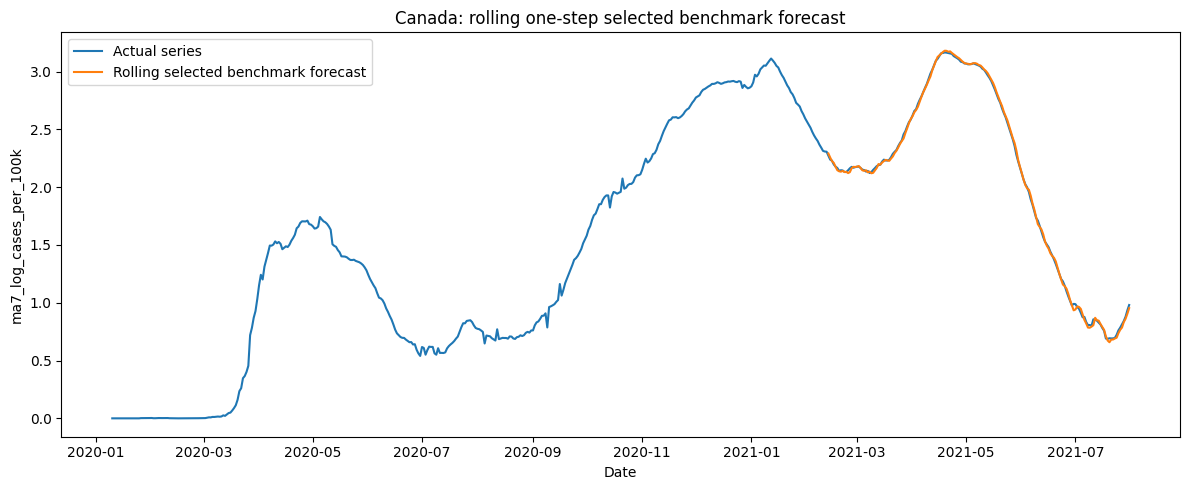

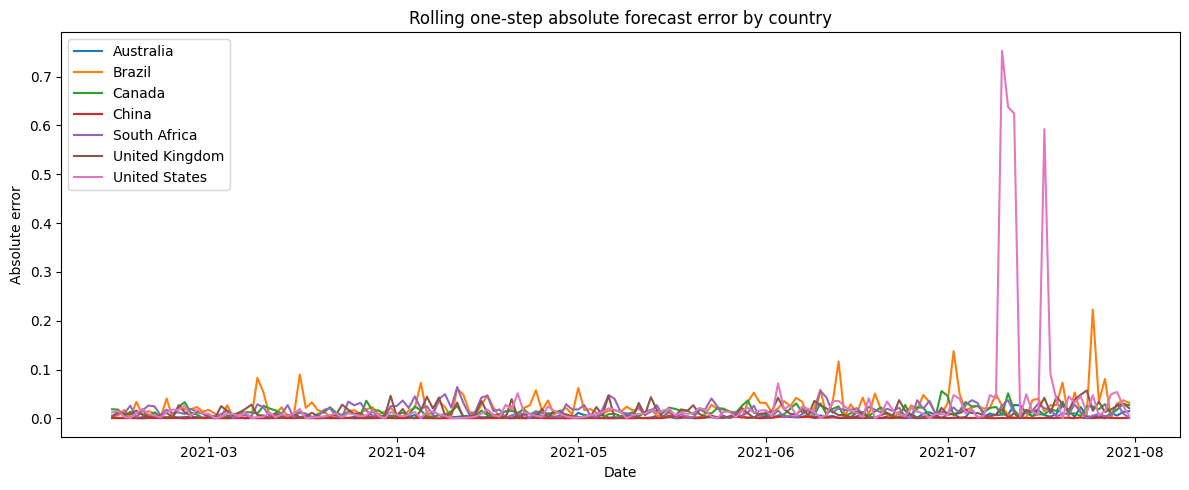

In [15]:
country = "Canada"

plot_df = rolling_benchmark_df.loc[
    rolling_benchmark_df["country"] == country
].copy()

actual_df = (
    panel_df.loc[panel_df["country"] == country, ["date", target_col]]
    .dropna()
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
plt.plot(actual_df["date"], actual_df[target_col], label="Actual series")
plt.plot(plot_df["date"], plot_df["forecast"], label="Rolling selected benchmark forecast")
plt.title(f"{country}: rolling one-step selected benchmark forecast")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

for country in selected_countries:
    temp = rolling_benchmark_df.loc[
        rolling_benchmark_df["country"] == country
    ]
    plt.plot(temp["date"], temp["abs_error"], label=country)

plt.title("Rolling one-step absolute forecast error by country")
plt.xlabel("Date")
plt.ylabel("Absolute error")
plt.legend()
plt.tight_layout()
plt.show()

We next evaluated the stronger country-specific benchmark for each country using expanding-window one-step-ahead forecasts on the transformed target series. The selected benchmark remained ETS for Australia, Brazil, South Africa, and the United Kingdom, and SARIMA for Canada, China, and the United States. Forecast errors were generally small, indicating that short-horizon dynamics in the smoothed series are already captured well by strong univariate models. This provides a demanding baseline for assessing whether cross-country dependence adds incremental forecast value beyond country-specific information alone.

## Multivariate Forecasting - VAR model

We check the recommended order for VAR model using metrics.


VAR data shape:
(569, 7)

Columns:
['Australia', 'Brazil', 'Canada', 'China', 'South Africa', 'United Kingdom', 'United States']

Missing values by column:
country
Australia         0
Brazil            0
Canada            0
China             0
South Africa      0
United Kingdom    0
United States     0
dtype: int64

Head:
country     Australia  Brazil  Canada     China  South Africa  United Kingdom  \
date                                                                            
2020-01-10        0.0     0.0     0.0  0.000043           0.0             0.0   
2020-01-11        0.0     0.0     0.0  0.000029           0.0             0.0   
2020-01-12        0.0     0.0     0.0  0.000443           0.0             0.0   
2020-01-13        0.0     0.0     0.0  0.000414           0.0             0.0   
2020-01-14        0.0     0.0     0.0  0.000414           0.0             0.0   

country     United States  
date                       
2020-01-10            0.0  
2020-01-11            0.

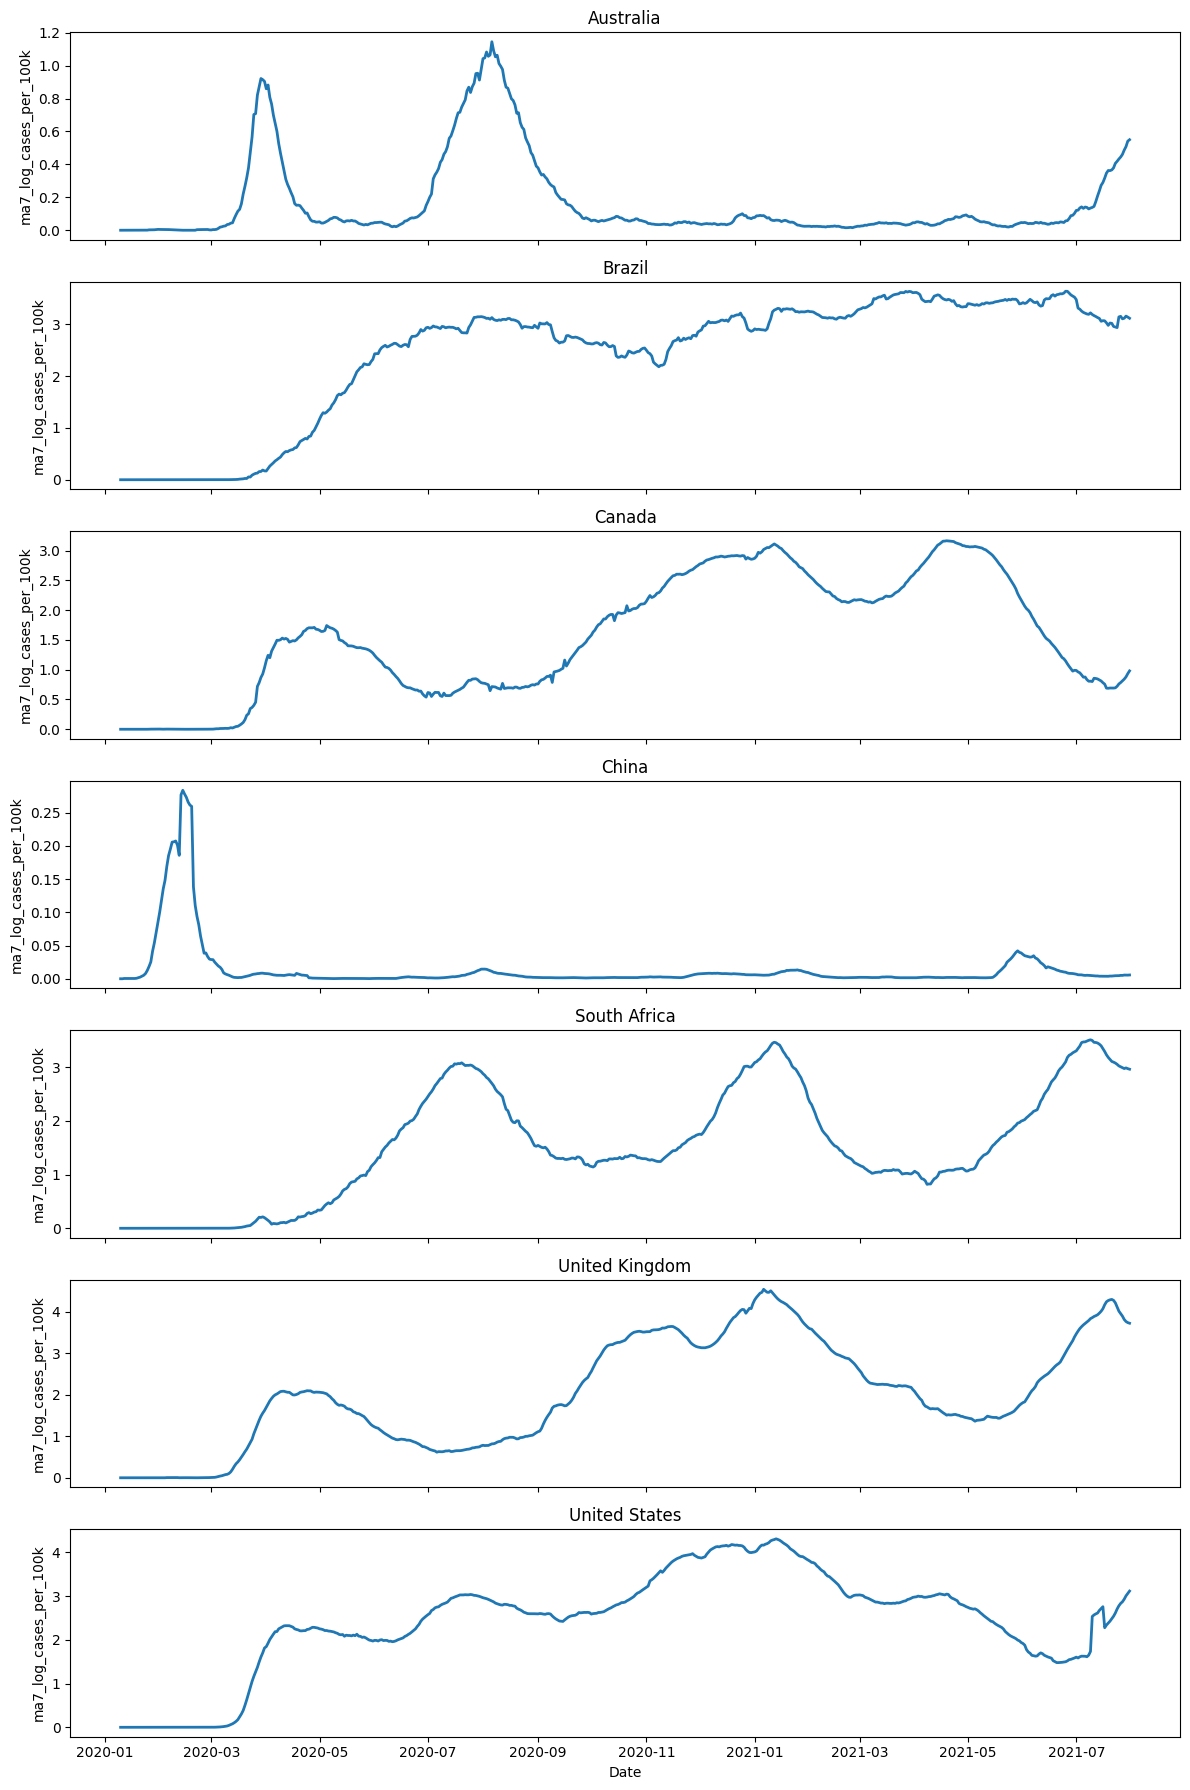


Initial VAR training sample shape:
(400, 7)
Train start: 2020-01-10 00:00:00
Train end: 2021-02-12 00:00:00

Lag selection summary:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -16.50      -16.43   6.839e-08      -16.47
1       -52.41      -51.84   1.732e-23      -52.18
2       -55.09     -54.01*   1.192e-24      -54.66
3       -55.35      -53.77   9.199e-25     -54.72*
4       -55.46      -53.38   8.258e-25      -54.63
5       -55.40      -52.81   8.768e-25      -54.37
6       -55.40      -52.32   8.727e-25      -54.18
7       -55.39      -51.81   8.851e-25      -53.97
8       -56.11      -52.02   4.346e-25      -54.49
9      -56.27*      -51.67  3.744e-25*      -54.45
10      -56.23      -51.14   3.912e-25      -54.21
11      -56.12      -50.52   4.423e-25      -53.90
12      -56.03      -49.93   4.888e-25      -53.61
13      -55.99      -49.39   5.130e-25      -53.38


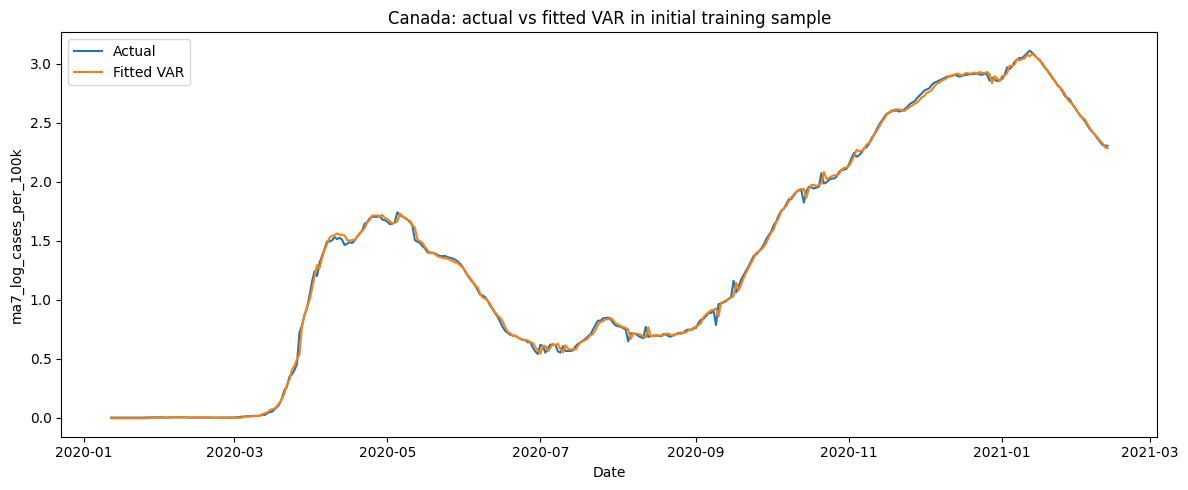

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR

target_col = "ma7_log_cases_per_100k"
initial_train_size = 400

# Build wide-format panel for VAR
var_df = (
    panel_df.loc[:, ["date", "country", target_col]]
    .dropna()
    .pivot(index="date", columns="country", values=target_col)
    .sort_index()
)

# Reorder columns to keep a consistent country order
var_df = var_df[selected_countries].copy()

print("VAR data shape:")
print(var_df.shape)

print("\nColumns:")
print(var_df.columns.tolist())

print("\nMissing values by column:")
print(var_df.isna().sum())

print("\nHead:")
print(var_df.head())

# Plot the aligned transformed series
fig, axes = plt.subplots(nrows=len(selected_countries), ncols=1, figsize=(12, 18), sharex=True)

for i, country in enumerate(selected_countries):
    axes[i].plot(var_df.index, var_df[country], linewidth=2)
    axes[i].set_title(country)
    axes[i].set_ylabel(target_col)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

# Split an initial training sample for lag selection
var_train = var_df.iloc[:initial_train_size].copy()

print("\nInitial VAR training sample shape:")
print(var_train.shape)
print("Train start:", var_train.index.min())
print("Train end:", var_train.index.max())

# Lag-order selection
maxlags = 14
var_model = VAR(var_train)
lag_selection = var_model.select_order(maxlags=maxlags)

print("\nLag selection summary:")
print(lag_selection.summary())

print("\nSelected lags by criterion:")
print("AIC:", lag_selection.aic)
print("BIC:", lag_selection.bic)
print("FPE:", lag_selection.fpe)
print("HQIC:", lag_selection.hqic)

# Optional: fit a provisional VAR using one chosen lag
# A conservative default is BIC; a less conservative option is HQIC.
selected_p = lag_selection.bic

if selected_p is None or selected_p < 1:
    selected_p = 1

print("\nChosen lag for provisional fitting:", selected_p)

var_result = var_model.fit(selected_p)

print("\nVAR summary:")
print(var_result.summary())

# Stability check
is_stable = var_result.is_stable(verbose=False)
print("\nIs the provisional VAR stable?", is_stable)

# Residual covariance matrix
print("\nResidual covariance matrix:")
print(var_result.sigma_u)

# Plot fitted values against actuals for one example country
example_country = "Canada"

fitted_df = var_result.fittedvalues.copy()
fitted_df.index = var_train.index[selected_p:]

actual_series = var_train.loc[fitted_df.index, example_country]

plt.figure(figsize=(12, 5))
plt.plot(actual_series.index, actual_series.values, label="Actual")
plt.plot(fitted_df.index, fitted_df[example_country].values, label="Fitted VAR")
plt.title(f"{example_country}: actual vs fitted VAR in initial training sample")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

**VAR lag order selection results:**

| Criterion | Selected lag |
|-----------|-------------|
| AIC / FPE | 9 |
| HQIC      | 3 |
| BIC       | 2 |

The information criteria disagree, which is common in multivariate time-series with moderate sample sizes. AIC/FPE favour longer lag structures that capture more dependence, while BIC penalises free parameters more aggressively.

A VAR(9) with 7 variables would introduce $7 \times (9 \times 7 + 1) = 448$ free parameters — far too many for reliable estimation on this dataset. We therefore evaluate **VAR(2)** and **VAR(3)** as parsimonious alternatives supported by the stricter criteria, while still allowing multi-day cross-country lead-lag effects. A companion eigenvalue stability check confirms both specifications are dynamically stable.

### Expanding-Window VAR Evaluation

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

target_col = "ma7_log_cases_per_100k"
initial_train_size = 400
var_orders = [2, 3]
example_country = "Canada"

expanding_benchmark_summary = rolling_benchmark_summary.copy()
expanding_benchmark_df = rolling_benchmark_df.copy()

var_df = (
    panel_df.loc[:, ["date", "country", target_col]]
    .dropna()
    .pivot(index="date", columns="country", values=target_col)
    .sort_index()
)

var_df = var_df[selected_countries].copy()


def run_expanding_var_forecast(var_df, selected_countries, p, initial_train_size):
    """Run expanding-window one-step-ahead forecasts for all countries using a VAR(p) model.

    At each forecast origin t (from initial_train_size to end of series),
    a VAR(p) is fitted on all observations up to t-1 using the wide-format
    panel, and a single one-step-ahead forecast is produced for all countries
    simultaneously.

    Args:
        var_df: Wide-format DataFrame indexed by date with one column per country,
            containing the target series (ma7_log_cases_per_100k).
        selected_countries (list[str]): Ordered list of country column names.
        p (int): VAR lag order.
        initial_train_size (int): Minimum number of observations before the first forecast.

    Returns:
        tuple:
            df_out (pd.DataFrame): Long-format forecast results with columns
                date, country, model, actual, forecast, error, abs_error, sq_error, success.
            summary_out (pd.DataFrame): Per-country RMSE and MAE summary.
    """
    records = []

    for t in range(initial_train_size, len(var_df)):
        train_df = var_df.iloc[:t].copy()
        test_date = var_df.index[t]
        actual_row = var_df.iloc[t].copy()

        try:
            model = VAR(train_df)
            result = model.fit(p)

            forecast_array = result.forecast(train_df.values[-p:], steps=1)[0]
            forecast_row = pd.Series(forecast_array, index=var_df.columns)

            for country in selected_countries:
                actual = actual_row[country]
                pred = forecast_row[country]
                error = actual - pred
                abs_error = abs(error)
                sq_error = error ** 2

                records.append({
                    "date": test_date,
                    "country": country,
                    "model": f"VAR({p})",
                    "actual": actual,
                    "forecast": pred,
                    "error": error,
                    "abs_error": abs_error,
                    "sq_error": sq_error,
                    "success": 1
                })

        except Exception:
            for country in selected_countries:
                actual = actual_row[country]
                records.append({
                    "date": test_date,
                    "country": country,
                    "model": f"VAR({p})",
                    "actual": actual,
                    "forecast": np.nan,
                    "error": np.nan,
                    "abs_error": np.nan,
                    "sq_error": np.nan,
                    "success": 0
                })

    df_out = pd.DataFrame(records)

    summary_out = (
        df_out
        .groupby(["country", "model"])
        .agg(
            n_forecasts=("forecast", "count"),
            n_success=("success", "sum"),
            rmse=("sq_error", lambda x: np.sqrt(np.nanmean(x))),
            mae=("abs_error", lambda x: np.nanmean(x))
        )
        .reset_index()
        .sort_values("country")
    )

    return df_out, summary_out


# Run VAR(2) and VAR(3)
expanding_var_results = {}
expanding_var_summaries = []

for p in var_orders:
    print(f"Running expanding-window VAR({p}) ...")
    df_p, summary_p = run_expanding_var_forecast(
        var_df=var_df,
        selected_countries=selected_countries,
        p=p,
        initial_train_size=initial_train_size
    )
    expanding_var_results[p] = df_p
    expanding_var_summaries.append(summary_p)

expanding_var_summary_all = pd.concat(expanding_var_summaries, ignore_index=True)

print("\nExpanding-window VAR summaries:")
print(expanding_var_summary_all)


benchmark_compare_df = expanding_benchmark_summary.copy().rename(columns={
    "model": "benchmark_model",
    "rmse": "benchmark_rmse",
    "mae": "benchmark_mae",
    "n_forecasts": "benchmark_n_forecasts",
    "n_success": "benchmark_n_success"
})

comparison_all = benchmark_compare_df.copy()

for p in var_orders:
    tmp = (
        expanding_var_summary_all.loc[expanding_var_summary_all["model"] == f"VAR({p})"]
        .copy()
        .rename(columns={
            "model": f"var{p}_model",
            "rmse": f"var{p}_rmse",
            "mae": f"var{p}_mae",
            "n_forecasts": f"var{p}_n_forecasts",
            "n_success": f"var{p}_n_success"
        })
    )
    comparison_all = comparison_all.merge(tmp, on="country", how="inner")

for p in var_orders:
    comparison_all[f"rmse_gain_var{p}"] = comparison_all["benchmark_rmse"] - comparison_all[f"var{p}_rmse"]
    comparison_all[f"mae_gain_var{p}"] = comparison_all["benchmark_mae"] - comparison_all[f"var{p}_mae"]
    comparison_all[f"var{p}_beats_benchmark_rmse"] = comparison_all[f"var{p}_rmse"] < comparison_all["benchmark_rmse"]
    comparison_all[f"var{p}_beats_benchmark_mae"] = comparison_all[f"var{p}_mae"] < comparison_all["benchmark_mae"]

comparison_all["best_model_by_rmse"] = comparison_all[
    ["benchmark_rmse", "var2_rmse", "var3_rmse"]
].idxmin(axis=1).replace({
    "benchmark_rmse": "Selected benchmark",
    "var2_rmse": "VAR(2)",
    "var3_rmse": "VAR(3)"
})

comparison_all["best_rmse"] = comparison_all[["benchmark_rmse", "var2_rmse", "var3_rmse"]].min(axis=1)

comparison_all["best_model_by_mae"] = comparison_all[
    ["benchmark_mae", "var2_mae", "var3_mae"]
].idxmin(axis=1).replace({
    "benchmark_mae": "Selected benchmark",
    "var2_mae": "VAR(2)",
    "var3_mae": "VAR(3)"
})

comparison_all["best_mae"] = comparison_all[["benchmark_mae", "var2_mae", "var3_mae"]].min(axis=1)

print("\nBenchmark vs VAR(2) vs VAR(3):")
print(
    comparison_all[[
        "country", "benchmark_model", "benchmark_rmse",
        "var2_rmse", "var3_rmse", "rmse_gain_var2", "rmse_gain_var3",
        "best_model_by_rmse", "benchmark_mae", "var2_mae", "var3_mae", "best_model_by_mae"
    ]].sort_values("country")
)


# Canada example plot
benchmark_plot_df = expanding_benchmark_df.loc[expanding_benchmark_df["country"] == example_country].copy()
var2_plot_df = expanding_var_results[2].loc[expanding_var_results[2]["country"] == example_country].copy()
var3_plot_df = expanding_var_results[3].loc[expanding_var_results[3]["country"] == example_country].copy()
actual_plot_df = (
    panel_df.loc[panel_df["country"] == example_country, ["date", target_col]]
    .dropna().reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
plt.plot(actual_plot_df["date"], actual_plot_df[target_col], label="Actual series")
plt.plot(benchmark_plot_df["date"], benchmark_plot_df["forecast"], label="Expanding selected benchmark")
plt.plot(var2_plot_df["date"], var2_plot_df["forecast"], label="Expanding VAR(2)")
plt.plot(var3_plot_df["date"], var3_plot_df["forecast"], label="Expanding VAR(3)")
plt.title(f"{example_country}: expanding-window one-step benchmark vs VAR(2) vs VAR(3)")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


# RMSE bar chart
plot_df = comparison_all.sort_values("country").copy()
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, plot_df["benchmark_rmse"], width=width, label="Selected benchmark RMSE")
plt.bar(x, plot_df["var2_rmse"], width=width, label="VAR(2) RMSE")
plt.bar(x + width, plot_df["var3_rmse"], width=width, label="VAR(3) RMSE")
plt.xticks(x, plot_df["country"], rotation=45)
plt.ylabel("RMSE")
plt.title("Expanding-window one-step RMSE: selected benchmark vs VAR(2) vs VAR(3)")
plt.legend()
plt.tight_layout()
plt.show()


# MAE bar chart
plt.figure(figsize=(12, 5))
plt.bar(x - width, plot_df["benchmark_mae"], width=width, label="Selected benchmark MAE")
plt.bar(x, plot_df["var2_mae"], width=width, label="VAR(2) MAE")
plt.bar(x + width, plot_df["var3_mae"], width=width, label="VAR(3) MAE")
plt.xticks(x, plot_df["country"], rotation=45)
plt.ylabel("MAE")
plt.title("Expanding-window one-step MAE: selected benchmark vs VAR(2) vs VAR(3)")
plt.legend()
plt.tight_layout()
plt.show()


# Error-difference plots
for p in var_orders:
    error_diff_df = expanding_benchmark_df.merge(
        expanding_var_results[p],
        on=["date", "country"],
        suffixes=("_benchmark", f"_var{p}")
    )
    error_diff_df[f"abs_error_diff_var{p}"] = (
        error_diff_df["abs_error_benchmark"] - error_diff_df[f"abs_error_var{p}"]
    )
    plt.figure(figsize=(12, 5))
    for country in selected_countries:
        temp = error_diff_df.loc[error_diff_df["country"] == country]
        plt.plot(temp["date"], temp[f"abs_error_diff_var{p}"], label=country)
    plt.axhline(0, linestyle="--")
    plt.title(f"Benchmark absolute error minus VAR({p}) absolute error by country")
    plt.xlabel("Date")
    plt.ylabel("Positive values favor VAR")
    plt.legend()
    plt.tight_layout()
    plt.show()


We compared the selected country-specific benchmark against two parsimonious multivariate specifications, VAR(2) and VAR(3), using expanding-window one-step-ahead forecasts on the transformed panel. The selected benchmark remained superior for Australia, Brazil, Canada, South Africa, and the United Kingdom. VAR models improved on the benchmark only for China and the United States, with the gain being economically meaningful mainly for the United States.

Increasing the lag length from 2 to 3 did not materially alter the overall conclusion. VAR(3) slightly improved performance for some countries such as Australia, Canada, and China, but these changes were not large enough to overturn the benchmark comparison. In particular, VAR(2) remained the strongest multivariate specification for the United States, which was also the clearest case where cross-country dependence appeared to add operational forecast value.

Overall, the evidence suggests that cross-country dependence does not provide broad and systematic short-horizon forecast gains once strong country-specific benchmark models are used. Its value appears limited, country-specific, and episodic rather than universal.

## robustness check - hhh4 model

We run the hhh4 model in R to check the robustness of our results.

comparison_with_hhh4 columns:
['country', 'benchmark_model', 'benchmark_n_forecasts', 'benchmark_n_success', 'benchmark_rmse', 'benchmark_mae', 'var2_model', 'var2_n_forecasts', 'var2_n_success', 'var2_rmse', 'var2_mae', 'var3_model', 'var3_n_forecasts', 'var3_n_success', 'var3_rmse', 'var3_mae', 'rmse_gain_var2', 'mae_gain_var2', 'var2_beats_benchmark_rmse', 'var2_beats_benchmark_mae', 'rmse_gain_var3', 'mae_gain_var3', 'var3_beats_benchmark_rmse', 'var3_beats_benchmark_mae', 'best_model_by_rmse', 'best_rmse', 'best_model_by_mae', 'best_mae', 'hhh4_full_rmse', 'hhh4_within_rmse', 'hhh4_full_mae', 'hhh4_within_mae', 'hhh4_full_n_forecasts', 'hhh4_within_n_forecasts', 'hhh4_rmse_gain_full_vs_within', 'hhh4_mae_gain_full_vs_within', 'hhh4_full_beats_within_rmse', 'hhh4_full_beats_within_mae']

hhh4 within vs full comparison:
model         country  hhh4_full_rmse  hhh4_within_rmse  hhh4_full_mae  \
0           Australia       90.476546         90.476546      54.819549   
1              Br

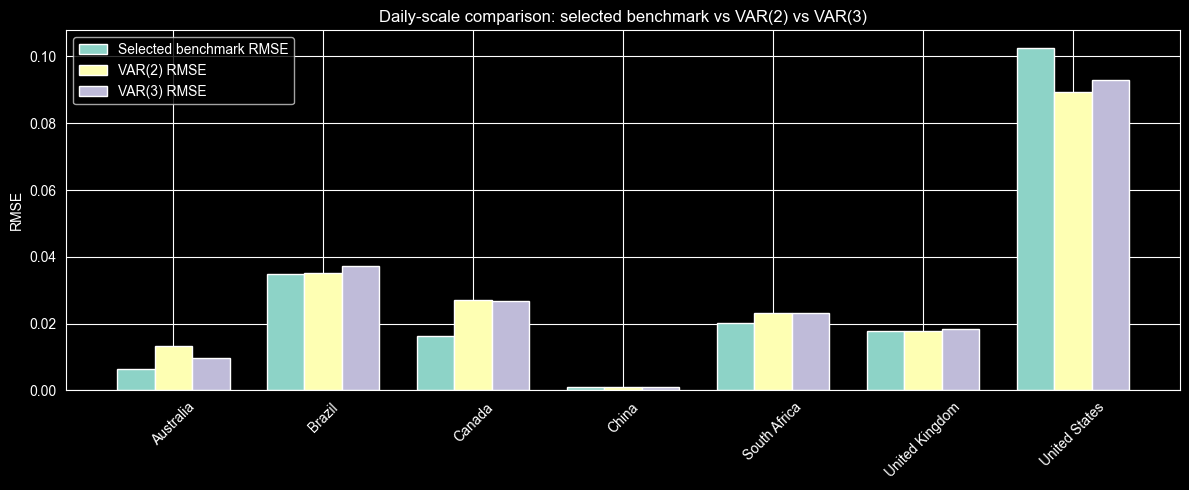

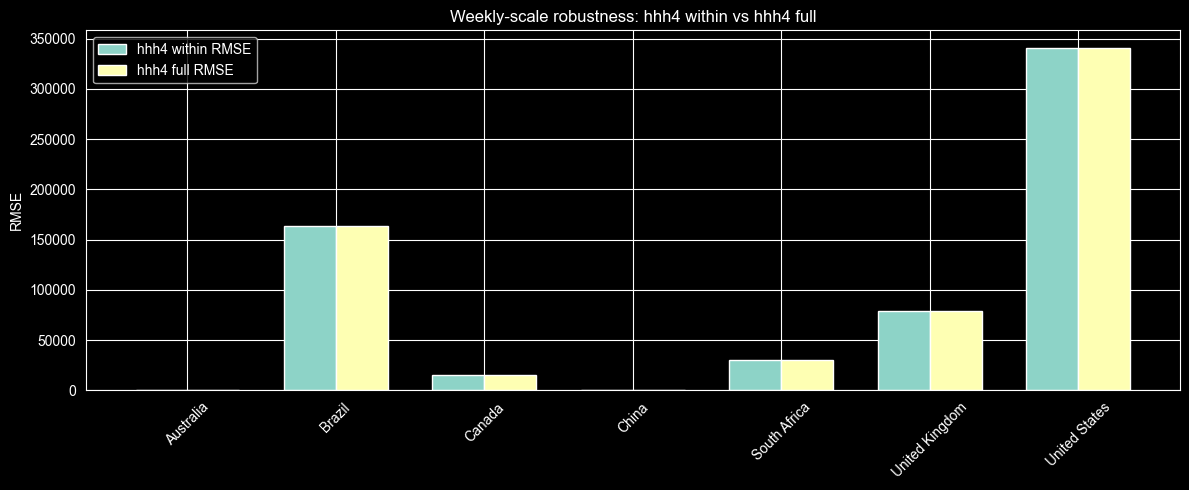

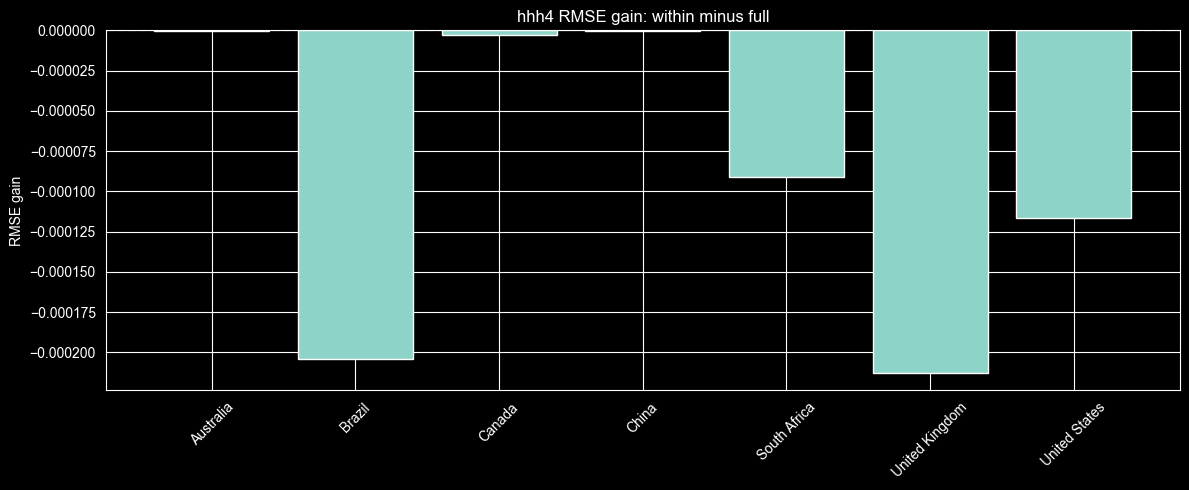

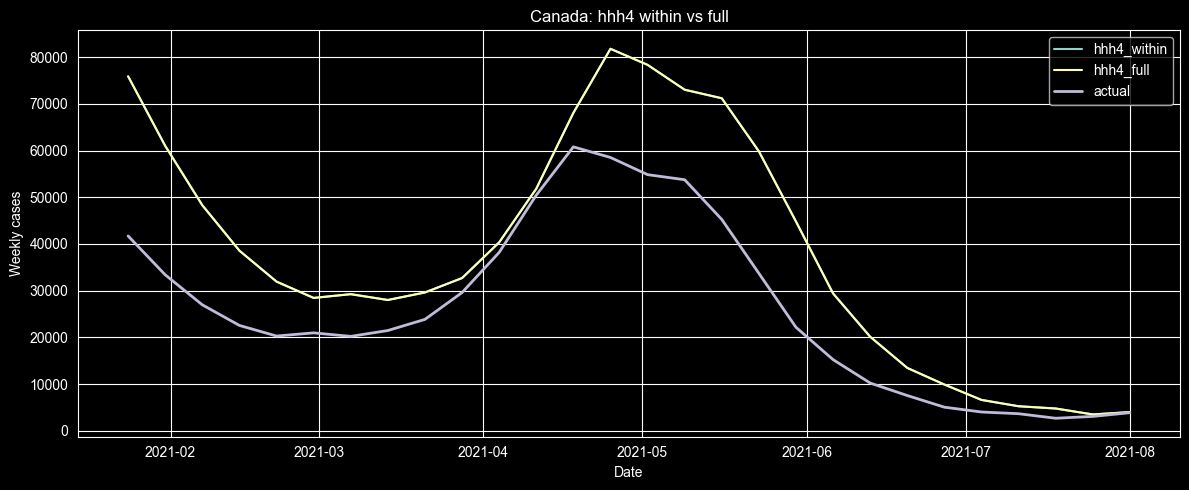

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("../Results/Figures", exist_ok=True)

# -----------------------------
# Read pre-computed results from committed CSVs
# (no dependency on upstream SARIMA/VAR cells)
# -----------------------------
comparison_with_hhh4 = pd.read_csv("comparison_with_hhh4.csv")

path_to_hhh4_exports = "RQ2_hhh4/CS3RQ2_hhh4/hhh4_exports/"
hhh4_summary_by_country = pd.read_csv(f"{path_to_hhh4_exports}/hhh4_summary_by_country.csv")
hhh4_forecasts_long = pd.read_csv(f"{path_to_hhh4_exports}/hhh4_forecasts_long.csv", parse_dates=["date"])

print("comparison_with_hhh4 columns:")
print(list(comparison_with_hhh4.columns))
print()

# -----------------------------
# Rebuild hhh4_compare from summary CSV
# -----------------------------
hhh4_rmse_wide = (
    hhh4_summary_by_country
    .pivot(index="country", columns="model", values="rmse")
    .reset_index()
    .rename(columns={"hhh4_within": "hhh4_within_rmse", "hhh4_full": "hhh4_full_rmse"})
)
hhh4_mae_wide = (
    hhh4_summary_by_country
    .pivot(index="country", columns="model", values="mae")
    .reset_index()
    .rename(columns={"hhh4_within": "hhh4_within_mae", "hhh4_full": "hhh4_full_mae"})
)
hhh4_compare = hhh4_rmse_wide.merge(hhh4_mae_wide, on="country", how="inner")
hhh4_compare["hhh4_rmse_gain_full_vs_within"] = (
    hhh4_compare["hhh4_within_rmse"] - hhh4_compare["hhh4_full_rmse"]
)

print("hhh4 within vs full comparison:")
print(hhh4_compare.sort_values("country"))

# -----------------------------
# Plot 1: benchmark vs VAR(2) vs VAR(3)
# -----------------------------
plot_df_main = comparison_with_hhh4.sort_values("country").copy()
x = np.arange(len(plot_df_main))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, plot_df_main["benchmark_rmse"], width=width, label="Selected benchmark RMSE")
plt.bar(x, plot_df_main["var2_rmse"], width=width, label="VAR(2) RMSE")
plt.bar(x + width, plot_df_main["var3_rmse"], width=width, label="VAR(3) RMSE")

plt.xticks(x, plot_df_main["country"], rotation=45)
plt.ylabel("RMSE")
plt.title("Daily-scale comparison: selected benchmark vs VAR(2) vs VAR(3)")
plt.legend()
plt.tight_layout()
plt.savefig("../Results/Figures/fig5_rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Plot 2: hhh4 within vs full
# -----------------------------
plot_df_hhh4 = hhh4_compare.sort_values("country").copy()
x = np.arange(len(plot_df_hhh4))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, plot_df_hhh4["hhh4_within_rmse"], width=width, label="hhh4 within RMSE")
plt.bar(x + width / 2, plot_df_hhh4["hhh4_full_rmse"], width=width, label="hhh4 full RMSE")

plt.xticks(x, plot_df_hhh4["country"], rotation=45)
plt.ylabel("RMSE")
plt.title("Weekly-scale robustness: hhh4 within vs hhh4 full")
plt.legend()
plt.tight_layout()
plt.savefig("../Results/Figures/fig6_hhh4_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Plot 3: hhh4 gain by country
# -----------------------------
plt.figure(figsize=(12, 5))
plt.bar(plot_df_hhh4["country"], plot_df_hhh4["hhh4_rmse_gain_full_vs_within"])
plt.axhline(0, linestyle="--")
plt.ylabel("RMSE gain")
plt.title("hhh4 RMSE gain: within minus full")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: Canada hhh4 example
# -----------------------------
example_country = "Canada"
hhh4_canada = hhh4_forecasts_long.loc[hhh4_forecasts_long["country"] == example_country].copy()

plt.figure(figsize=(12, 5))
for model_name in ["hhh4_within", "hhh4_full"]:
    temp = hhh4_canada.loc[hhh4_canada["model"] == model_name]
    plt.plot(temp["date"], temp["forecast"], label=model_name)

actual_canada = hhh4_canada[["date", "actual"]].drop_duplicates().sort_values("date")
plt.plot(actual_canada["date"], actual_canada["actual"], label="actual", linewidth=2)
plt.title(f"{example_country}: hhh4 within vs full")
plt.xlabel("Date")
plt.ylabel("Weekly cases")
plt.legend()
plt.tight_layout()
plt.show()

The hhh4 results reinforce the VAR findings. Adding cross-country spillover (the `hhh4_full` specification with equal-weight connectivity) does not improve forecast accuracy relative to the within-country-only model (`hhh4_within`) for any of the seven countries. The RMSE differences are negligible — on the order of $10^{-4}$ to $10^{-7}$ relative to RMSE values in the tens of thousands — and the estimated neighbourhood coefficient is large and negative, indicating a model artefact under the equal-weight assumption rather than genuine cross-country signal.

This result is not a failure of the framework: `hhh4` is specifically designed to detect cross-country epidemic transmission. Its inability to improve on the within-country specification across all seven countries and 28 weekly forecast origins is strong evidence that cross-country spillover in this dataset does not represent a stable, operationally extractable signal under the assumptions tested.

## Conclusion

Across both the primary daily-scale comparison and the weekly endemic-epidemic robustness check, cross-country dependence does not provide broad or systematic forecast improvements beyond strong within-country baselines. In the daily benchmark-vs-VAR comparison, gains are limited to the United States (VAR(2)) and marginally to China. In the weekly endemic-epidemic framework, adding the cross-country spillover component does not improve forecast accuracy for any country. Taken together, the results suggest that cross-country dependence may be descriptively present (as established in RQ1), but its operational forecast value is limited, country-specific, and not universal.